In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Sale Report.csv', encoding='unicode_escape')
sns.set_theme(style="whitegrid")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 9271, Columns: 7


,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


In [2]:
print(df.isnull().sum())

index          0
SKU Code      83
Design No.    36
Stock         36
Category      45
Size          36
Color         45
dtype: int64


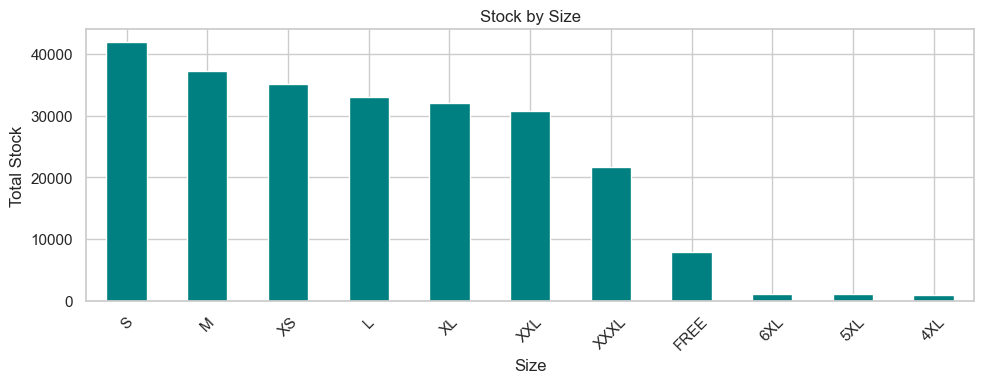

In [3]:
size_sales = df.groupby('Size')['Stock'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
size_sales.plot(kind='bar', color='teal')
plt.title('Stock by Size')
plt.xlabel('Size')
plt.ylabel('Total Stock')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/chart_size_sales.png')
plt.show()

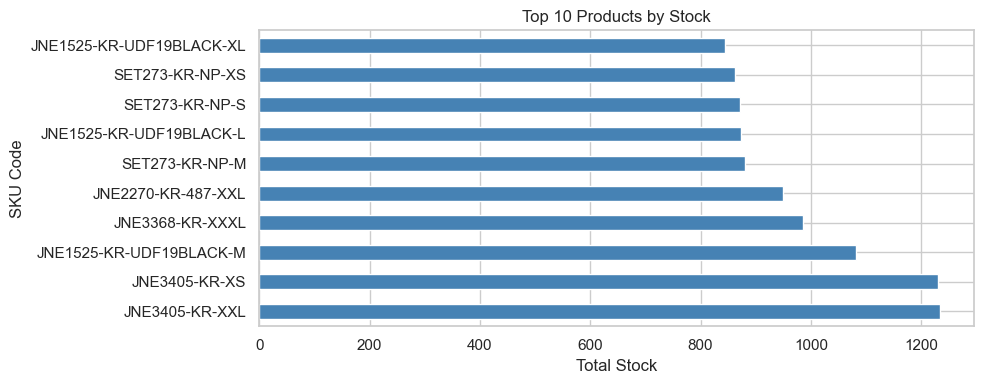

In [4]:
# Cell 4 — Top 10 Products by Stock
top_products = df.groupby('SKU Code')['Stock'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Stock')
plt.xlabel('Total Stock')
plt.tight_layout()
plt.savefig('../data/chart_top_products.png')
plt.show()

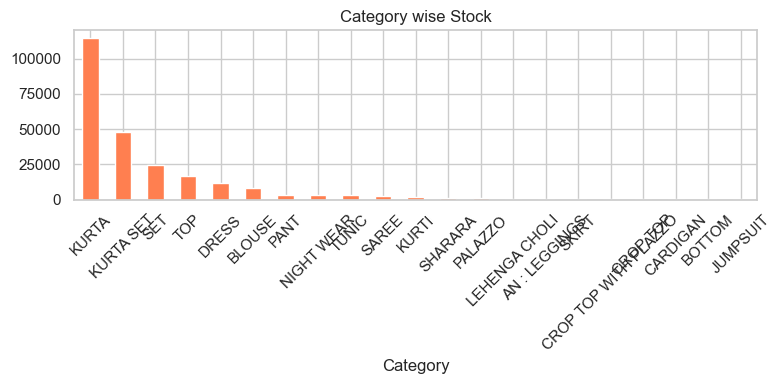

In [5]:
# Cell 5 — Category wise Stock
cat_stock = df.groupby('Category')['Stock'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cat_stock.plot(kind='bar', color='coral')
plt.title('Category wise Stock')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/chart_cat_stock.png')
plt.show()

In [6]:
# Cell 6 — Summary
print("=== Product Analysis Summary ===\n")
print(f"Total Products: {df['SKU Code'].nunique()}")
print(f"Total Stock: {df['Stock'].sum():,}")
print(f"Top Size: {df.groupby('Size')['Stock'].sum().idxmax()}")
print(f"Top Category: {df.groupby('Category')['Stock'].sum().idxmax()}")

=== Product Analysis Summary ===

Total Products: 9170
Total Stock: 242,386.0
Top Size: S
Top Category: KURTA
